In [146]:
import os, sys
import numpy as np
import pandas as pd

from utils.plot_utils import setup_matplotlib

In [147]:
setup_matplotlib()

# === Config ===
train_trajs = ["random","square","chirp"]
test_trajs = ["melon"]

# === File paths ===
OUT_FOLDER = os.path.join(
    "..",
    "identification",
    "out",
    "predictions",
    "real"
)

# Ensure the output folder exists
os.makedirs(OUT_FOLDER, exist_ok=True)

# Construct file paths
train_name = "_".join(train_trajs)
test_name = "_".join(test_trajs)

file_lstm = os.path.join(
    OUT_FOLDER,
    f"lstm_{train_name}_model_multistep",
    f"{test_name}_multistep.parquet"
)

file_base = os.path.join(
    OUT_FOLDER,
    "baseline_model_multistep",
    f"{test_name}_multistep.parquet"
)

file_neur = os.path.join(
    OUT_FOLDER,
    f"neural_{train_name}_model_multistep",
    f"{test_name}_multistep.parquet"
)

# file_phys = os.path.join(
#     OUT_FOLDER,
#     f"physics_model_multistep",
#     f"{test_name}_multistep.parquet"
# )
#
# file_res = os.path.join(
#     OUT_FOLDER,
#     f"residual_{train_name}_model_multistep",
#     f"{test_name}_multistep.parquet"
# )

print("LSTM file path:", file_lstm)
print("Baseline file path:", file_base)

# === Read CSVs ===
df_lstm = pd.read_parquet(file_lstm)
df_base = pd.read_parquet(file_base)
df_neur = pd.read_parquet(file_neur)
# df_phys = pd.read_parquet(file_phys)
# df_res = pd.read_parquet(file_res)

print("✅ Loaded datasets:")
print(f"  LSTM model: {df_lstm.shape}")
print(f"  Baseline model: {df_base.shape}")
print(f"  Neural model: {df_neur.shape}")
# print(f"  Physics model: {df_phys.shape}")
# print(f"  Residual model: {df_res.shape}")

LSTM file path: ..\identification\out\predictions\real\lstm_random_square_chirp_model_multistep\melon_multistep.parquet
Baseline file path: ..\identification\out\predictions\real\baseline_model_multistep\melon_multistep.parquet
✅ Loaded datasets:
  LSTM model: (6449, 613)
  Baseline model: (6449, 613)
  Neural model: (6449, 613)


In [148]:
# ---------------------------------------------------------
# === Conversions ===
# ---------------------------------------------------------
def so3_log_to_quat_np(r, eps=1e-12):
    """
    Convert an SO(3) log-vector r = (rx, ry, rz) into a quaternion [x,y,z,w].
    Vectorized and numerically stable.
    """
    theta = np.linalg.norm(r, axis=-1, keepdims=True)
    small = theta < 1e-6

    half_theta = 0.5 * theta

    # general
    v = (np.sin(half_theta) / (theta + eps)) * r
    w = np.cos(half_theta)

    # small-angle
    v = np.where(small, 0.5 * r, v)
    w = np.where(small, 1.0, w)

    return np.concatenate([v, w], axis=-1)



def quat_to_euler_np(q):
    """Quaternion [x, y, z, w] → Euler [roll, pitch, yaw] (ZYX, radians)."""
    x, y, z, w = np.moveaxis(q, -1, 0)

    # yaw (Z)
    siny_cosp = 2.0 * (w * z + x * y)
    cosy_cosp = 1.0 - 2.0 * (y * y + z * z)
    yaw = np.arctan2(siny_cosp, cosy_cosp)

    # pitch (Y)
    sinp = 2.0 * (w * y - z * x)
    pitch = np.where(np.abs(sinp) >= 1,
                     np.sign(sinp) * np.pi / 2,
                     np.arcsin(sinp))

    # roll (X)
    sinr_cosp = 2.0 * (w * x + y * z)
    cosr_cosp = 1.0 - 2.0 * (x * x + y * y)
    roll = np.arctan2(sinr_cosp, cosr_cosp)

    return np.stack([roll, pitch, yaw], axis=-1)


def add_rotation_columns(df):
    """
    Efficiently adds quaternion and Euler angle columns for all
    (rx*, ry*, rz*) rotation-vector triplets.
    Avoids DataFrame fragmentation by concatenating once.
    """
    df = df.copy()
    new_cols = {}   # store new columns here

    # Find all rotation-vector groups
    rx_cols = [c for c in df.columns if c.startswith("rx")]

    for rx_col in rx_cols:
        suffix = rx_col[2:]              # "" or "_pred_h1"
        ry_col = f"ry{suffix}"
        rz_col = f"rz{suffix}"

        if ry_col not in df.columns or rz_col not in df.columns:
            continue

        # Extract rotation vectors
        r = df[[rx_col, ry_col, rz_col]].to_numpy(float)

        # Convert to quaternion (N,4)
        q = so3_log_to_quat_np(r)

        # Quaternion columns
        new_cols[f"qx{suffix}"] = q[:, 0]
        new_cols[f"qy{suffix}"] = q[:, 1]
        new_cols[f"qz{suffix}"] = q[:, 2]
        new_cols[f"qw{suffix}"] = q[:, 3]

        # Euler angles (N,3)
        e = quat_to_euler_np(q)

        new_cols[f"roll{suffix}"]  = e[:, 0]
        new_cols[f"pitch{suffix}"] = e[:, 1]
        new_cols[f"yaw{suffix}"]   = e[:, 2]

        # Degrees
        new_cols[f"roll{suffix}_deg"]  = np.degrees(e[:, 0])
        new_cols[f"pitch{suffix}_deg"] = np.degrees(e[:, 1])
        new_cols[f"yaw{suffix}_deg"]   = np.degrees(e[:, 2])

    # One-shot concat — avoids fragmentation
    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

    return df



# ---------------------------------------------------------
# === Apply to all dataframes ===
# ---------------------------------------------------------
df_base, df_lstm, df_neur = [
    add_rotation_columns(df)
    for df in [df_base, df_lstm, df_neur]#, df_phys, df_res]
]

In [149]:
import numpy as np

# === Quaternion utilities ===
def quat_conj(q):
    """ q = [x, y, z, w] """
    return np.array([-q[0], -q[1], -q[2], q[3]])

def quat_mul(q1, q2):
    """ Hamilton product, both q=[x,y,z,w] """
    x1, y1, z1, w1 = q1
    x2, y2, z2, w2 = q2
    return np.array([
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
        w1*w2 - x1*x2 - y1*y2 - z1*z2
    ])

def quat_geodesic_error(q_true, q_pred):
    """Geodesic distance e_R = 2 atan2(||v||, w)."""
    qr = quat_mul(quat_conj(q_true), q_pred)
    v = qr[:3]
    w = qr[3]
    return 2 * np.arctan2(np.linalg.norm(v), w)

# === Core metric function ===
def compute_errors(df, max_horizon):
    """
    Returns dict:
      {
        'pos': {h: MAE_pos_h},
        'omega': {h: MAE_omega_h},
        'rot': {h: MAE_rot_h}
      }
    """
    errs_pos = {}
    errs_omega = {}
    errs_rot = {}

    for h in range(1, max_horizon + 1):

        # Align truth and predicted horizon=h
        true_pos = df[['x','y','z']].shift(-h+1).dropna().values
        pred_pos = np.vstack([df[f'{s}_pred_h{h}'].dropna().values for s in ['x','y','z']]).T
        min_len = min(len(true_pos), len(pred_pos))
        pos_err = np.linalg.norm(true_pos[:min_len] - pred_pos[:min_len], axis=1)
        errs_pos[h] = pos_err.mean()

        true_omega = df[['wx','wy','wz']].shift(-h+1).dropna().values
        pred_omega = np.vstack([df[f'{s}_pred_h{h}'].dropna().values for s in ['wx','wy','wz']]).T
        min_len = min(len(true_omega), len(pred_omega))
        omega_err = np.linalg.norm(true_omega[:min_len] - pred_omega[:min_len], axis=1)
        errs_omega[h] = omega_err.mean()

        # Orientation
        true_q = df[['qx','qy','qz','qw']].shift(-h+1).dropna().values
        pred_q = df[[f'qx_pred_h{h}', f'qy_pred_h{h}', f'qz_pred_h{h}', f'qw_pred_h{h}']].dropna().values
        min_len = min(len(true_q), len(pred_q))
        rot_err = np.array([
            quat_geodesic_error(true_q[i], pred_q[i])
            for i in range(min_len)
        ])
        errs_rot[h] = rot_err.mean()

    return {
        "pos": errs_pos,
        "omega": errs_omega,
        "rot": errs_rot
    }

In [150]:
# --- Config ---
max_horizon = 50

metrics_base  = compute_errors(df_base,  max_horizon)
metrics_lstm  = compute_errors(df_lstm,  max_horizon)
metrics_neur  = compute_errors(df_neur,  max_horizon)
# metrics_phys  = compute_errors(df_phys,  max_horizon)
# metrics_res   = compute_errors(df_res,   max_horizon)

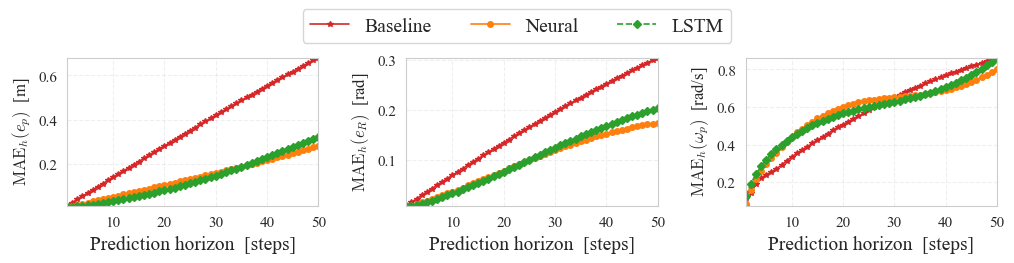

In [151]:
import matplotlib.pyplot as plt

# ============================================================
# === FIGURE: Position, Angular velocity, Orientation errors ===
# ============================================================

fig, axs = plt.subplots(1, 3, figsize=(12, 2), sharex=True)

metric_names = ["pos", "rot", "omega"]
ylabels = [r"$\mathrm{MAE}_h (e_p)$  [m]", r"$\mathrm{MAE}_h (e_R)$  [rad]",  r"$\mathrm{MAE}_h (\omega_p)$  [rad/s]"]

model_metrics = {
    "Baseline":   metrics_base,
    # "Physics":    metrics_phys,
    "Neural":     metrics_neur,
    # "Residual":   metrics_res,
    "LSTM":       metrics_lstm,
}

model_styles = {
    "Baseline": ('*-', 'tab:red'),
    "Physics": ('s-', 'tab:blue'),
    "Neural": ('o-', 'tab:orange'),
    "Residual": ('^-', 'tab:purple'),
    "LSTM": ('D--', 'tab:green'),
}

for i, metric in enumerate(metric_names):
    ax = axs[i]

    # Plot each model
    for model_name, mm in model_metrics.items():
        horizons = np.array(list(mm[metric].keys()))
        values   = np.array(list(mm[metric].values()))

        marker, color = model_styles[model_name]
        ax.plot(horizons, values, marker, color=color,
                linewidth=1.2, markersize=4, label=model_name)

    ax.set_ylabel(ylabels[i], fontsize=12)
    min_val = min(metrics_base[metric].values())
    max_val = max(metrics_base[metric].values())
    ax.set_ylim(min_val, max_val)
    ax.set_xlabel("Prediction horizon  [steps]", fontsize=14)
    ax.grid(True, alpha=0.3)

# === Shared Legend ===
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncols=5,
           bbox_to_anchor=(0.5, 1.15), fontsize=14)

# plt.subplots_adjust(top=0.9, bottom=0.1, hspace=0, wspace=0.3)
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.subplots_adjust(top=0.86, bottom=0.12, hspace=0.25, wspace=0.35)

# plt.savefig("new_metrics_models.pdf", bbox_inches='tight')
plt.show()


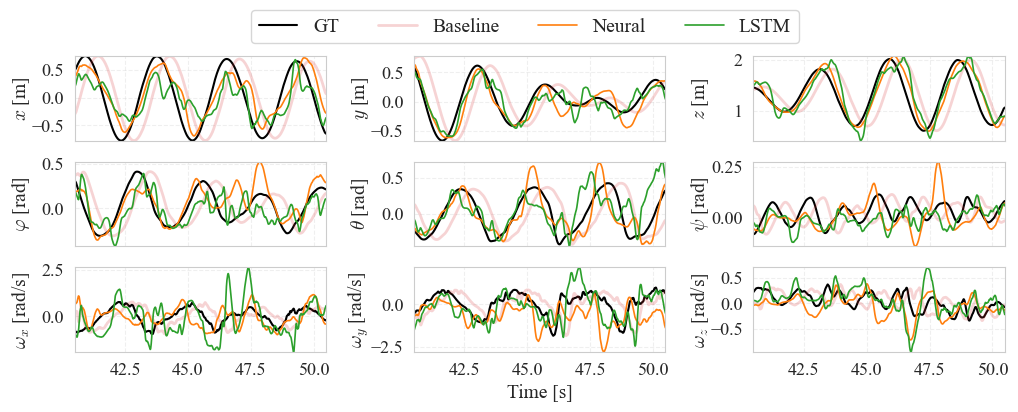

In [152]:
def plot_multistate_predictions(df_base, df_lstm,# df_neur, df_phys, df_res,
                                h=50, N_start=0, N_end=None):
    """
    Create a 4x3 grid of time-series plots comparing true vs. predicted trajectories
    (h-step ahead) for each state variable.
    """

    if N_end is None:
        N_end = len(df_base) - h

    # --- State order (12 total) ---
    state_names = [
        "x", "y", "z",
        "roll", "pitch", "yaw",
        # "vx", "vy", "vz",
        "wx", "wy", "wz"
    ]

    # --- Fancy axis labels ---
    state_labels = [
        [r"$x$ [m]", r"$y$ [m]", r"$z$ [m]"],
        [r'$\varphi$ [rad]', r'$\theta$ [rad]', r'$\psi$ [rad]'],
        # [r"$v_x$ [m/s]", r"$v_y$ [m/s]", r"$v_z$ [m/s]"],
        [r"$\omega_x$ [rad/s]", r"$\omega_y$ [rad/s]", r"$\omega_z$ [rad/s]"]
    ]

    # --- Figure setup ---
    fig, axs = plt.subplots(3, 3, figsize=(12, 4), sharex=True)
    t = df_base["t"].values

    for r in range(4):
        for c in range(3):
            idx = r * 3 + c
            if idx >= len(state_names):
                continue

            state = state_names[idx]
            pred_col = f"{state}_pred_h{h}"
            ax = axs[r, c]

            # --- Smoothed signals ---
            neur = df_neur[pred_col][N_start:N_end].rolling(10, min_periods=1, center=True).mean()
            # res  = df_res[pred_col][N_start:N_end].rolling(10, min_periods=1, center=True).mean()
            lstm = df_lstm[pred_col][N_start:N_end].rolling(10, min_periods=1, center=True).mean()
            base = df_base[pred_col][N_start:N_end].rolling(10, min_periods=1, center=True).mean()
            # phys = df_phys[pred_col][N_start:N_end].rolling(10, min_periods=1, center=True).mean()
            true = df_base[state][N_start + h:N_end + h].rolling(10, min_periods=1, center=True).mean()

            # --- Plot ---
            ax.plot(t[N_start + h:N_end + h], true, 'k-', label='GT', linewidth=1.5)
            ax.plot(t[N_start + h:N_end + h], base, '-', color='tab:red', label='Baseline', linewidth=2, alpha=0.2)
            # ax.plot(t[N_start + h:N_end + h], res, '-', color='tab:purple', label='Residual', linewidth=1.2)
            ax.plot(t[N_start + h:N_end + h], neur, '-', color='tab:orange', label='Neural', linewidth=1.2)
            ax.plot(t[N_start + h:N_end + h], lstm, '-', color='tab:green', label='LSTM', linewidth=1.2)
            # ax.plot(t[N_start + h:N_end + h], phys, '--', color='tab:blue', label='Physics', linewidth=1.2)

            # --- Aesthetics ---
            ax.set_ylabel(state_labels[r][c], fontsize=14, labelpad=10)
            ax.grid(True, alpha=0.3)

            # make tick numbers bigger
            ax.tick_params(labelsize=13, width=1.2, length=4)

            if (r == 2) and (c == 1):
                ax.set_xlabel("Time [s]", fontsize=14)

    # --- Align y-labels properly ---
    fig.align_ylabels(axs[:, 0])

    # --- Shared legend (like 2nd figure) ---
    handles, labels = [], []
    for ax in axs.flat:
        h, l = ax.get_legend_handles_labels()
        for handle, label in zip(h, l):
            if label not in labels:
                handles.append(handle)
                labels.append(label)

    fig.legend(handles, labels, loc='upper center', ncols=6,
               bbox_to_anchor=(0.5, 1), fontsize=14, frameon=True)

    labelx = -0.17  # axes coords

    for ax in axs.flat:
        ax.yaxis.set_label_coords(labelx, 0.5)

    plt.subplots_adjust(top=0.86, bottom=0.12, hspace=0.25, wspace=0.35)

    # plt.savefig('new_lineplots_models.pdf', bbox_inches='tight')
    plt.show()

plot_multistate_predictions(df_base, df_lstm, h=50, N_start=4000, N_end=5000)

In [153]:
lambda_ = .1
N = 50
weights = np.exp(-lambda_ * np.arange(N))
weights = weights / weights.sum()  # normalize to 1
for w in weights:
    print(w)

0.09580813208007738
0.08669078285818539
0.0784410641289165
0.07097640993440194
0.06422211150650607
0.05811056955636445
0.05258061771797984
0.04757691037467271
0.04304936874154711
0.038952679660179436
0.0352458420892986
0.03189175675258409
0.028856854836639065
0.02611076202302299
0.023625994491863506
0.021377683854549582
0.01934332826253966
0.017502567201298388
0.01583697771542371
0.014329890025517017
0.012966220691428072
0.011732321652116209
0.010615843631268213
0.009605612541590213
0.00869151765078632
0.007864410389951466
0.007116012791618858
0.006438834641079267
0.005826098511794658
0.005271671934635424
0.004770006022068151
0.004316079933024124
0.003905350622634365
0.0035337073739096056
0.0031974306563029983
0.0028931548993982297
0.0026178348091495805
0.002368714889555565
0.0021433018647287905
0.0019393397253528561
0.0017547871497828457
0.00158779707381219
0.0014366982046332744
0.0012999782939772712
0.001176269003025185
0.0010643322076130412
0.0009630476066690965
0.000871401509864176

In [154]:
import numpy as np
import matplotlib.pyplot as plt

def plot_multistate_boxplots(df_base, df_lstm, df_neur, df_res,
                             h=50, N_start=0, N_end=None, max_outliers=None):
    """
    Create a 4x3 grid of boxplots showing absolute errors for each model and state.
    Matches the aesthetic of plot_multistate_predictions.

    Args:
        df_base, df_lstm, df_neur, df_res : DataFrames
            Containing columns like '<state>_pred_h<h>'.
        h : int
            Prediction horizon.
        N_start, N_end : int
            Index range for samples.
        max_outliers : int or None
            If set, limits the number of largest error samples kept (useful to reduce extreme tails).
    """

    if N_end is None:
        N_end = len(df_base) - h

    # --- State order (12 total) ---
    state_names = [
        "x", "y", "z",
        "roll", "pitch", "yaw",
        "vx", "vy", "vz",
        "wx", "wy", "wz"
    ]

    # --- Fancy axis labels ---
    state_labels = [
        [r"$x$ [m]", r"$y$ [m]", r"$z$ [m]"],
        [r'$\varphi$ [rad]', r'$\theta$ [rad]', r'$\psi$ [rad]'],
        [r"$v_x$ [m/s]", r"$v_y$ [m/s]", r"$v_z$ [m/s]"],
        [r"$\omega_x$ [rad/s]", r"$\omega_y$ [rad/s]", r"$\omega_z$ [rad/s]"]
    ]

    # --- Model colors ---
    colors = {
        "Baseline": "tab:red",
        "Residual": "tab:purple",
        "Neural": "tab:orange",
        "LSTM": "tab:green",
    }

    fig, axs = plt.subplots(4, 3, figsize=(12, 6), dpi=100)
    axs = axs.flatten()

    for r in range(4):
        for c in range(3):
            idx = r * 3 + c
            if idx >= len(state_names):
                continue

            state = state_names[idx]
            pred_col = f"{state}_pred_h{h}"
            ax = axs[idx]

            # --- Compute absolute errors ---
            true = df_base[state].values[N_start + h:N_end + h]
            base = np.abs(df_base[pred_col].values[N_start:N_end] - true)
            neur = np.abs(df_neur[pred_col].values[N_start:N_end] - true)
            lstm = np.abs(df_lstm[pred_col].values[N_start:N_end] - true)
            res  = np.abs(df_res[pred_col].values[N_start:N_end] - true)

            # --- Optionally limit outliers ---
            if max_outliers is not None:
                def limit_outliers(arr, n=max_outliers):
                    if len(arr) > n:
                        cutoff = np.partition(arr, -n)[-n]  # nth largest
                        arr = np.clip(arr, None, cutoff)
                    return arr
                base, neur, lstm, res = map(limit_outliers, [base, neur, lstm, res])

            # --- Prepare data ---
            data = [base, res, neur, lstm]
            labels = list(colors.keys())

            # --- Boxplot ---
            box = ax.boxplot(data, patch_artist=True, labels=labels,
                             widths=0.55,
                             showfliers=False,
                             medianprops=dict(color='black', linewidth=1.2),
                             boxprops=dict(linewidth=1.1),
                             whiskerprops=dict(linewidth=1.0),
                             capprops=dict(linewidth=1.0),
                             flierprops=dict(marker='.', markersize=2, alpha=0.4))

            # --- Color boxes ---
            for patch, key in zip(box['boxes'], colors.keys()):
                patch.set_facecolor(colors[key])
                patch.set_alpha(0.6)

            # # --- Style ---
            # ax.set_ylabel(state_labels[r][c], fontsize=14, labelpad=10)
            # ax.grid(True, alpha=0.3)
            # ax.tick_params(labelsize=13, width=1.2, length=4)
            # ax.set_xticklabels(labels, rotation=20, fontsize=12)
            # --- Style ---
            ax.set_ylabel(state_labels[r][c], fontsize=14, labelpad=10)
            ax.grid(True, alpha=0.3)
            ax.tick_params(labelsize=13, width=1.2, length=4)

            # REMOVE x labels
            ax.set_xticks([])
            ax.set_xlabel("")


    # --- Shared legend ---
    legend_elements = [
        plt.Line2D([0], [0], color=c, lw=6, label=label, alpha=0.6)
        for label, c in colors.items()
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncols=4,
               bbox_to_anchor=(0.5, .98), fontsize=14, frameon=True)
    fig.align_ylabels()
    plt.subplots_adjust(top=0.86, bottom=0.12, hspace=0.25, wspace=0.4)
    plt.savefig('boxplots_models.pdf')
    plt.show()

# Standard usage
plot_multistate_boxplots(df_base, df_lstm, df_neur, df_res, h=50, N_start=0, N_end=None, max_outliers=1)

NameError: name 'df_res' is not defined